In [19]:
# ================================
# 1. Import Libraries
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier

print("All libraries imported successfully!")

All libraries imported successfully!


In [20]:
import sys
print(sys.version)


3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


In [21]:
train_df = pd.read_csv("../dataset/KDDTrain+.csv")

print("Training data loaded")
print("Dataset shape:", train_df.shape)

train_df.head()

Training data loaded
Dataset shape: (125973, 38)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,classnum
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [22]:
print("Number of columns:", train_df.shape[1])

train_df.columns

Number of columns: 38


Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted',
       'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
       'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
       'serror_rate', 'srv_serror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'dst_host_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class', 'classnum'],
      dtype='object')

In [23]:
# Target column
y = train_df["class"]

# Encode attack labels (multi-class)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("Attack classes:")
print(label_encoder.classes_)

# Save label encoder
with open("../model/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

Attack classes:
['back' 'buffer_overflow' 'ftp_write' 'guess_passwd' 'imap' 'ipsweep'
 'land' 'loadmodule' 'multihop' 'neptune' 'nmap' 'normal' 'perl' 'phf'
 'pod' 'portsweep' 'rootkit' 'satan' 'smurf' 'spy' 'teardrop'
 'warezclient' 'warezmaster']


In [24]:
# Drop label columns from features
X = train_df.drop(["class", "classnum"], axis=1)

categorical_cols = ["protocol_type", "service", "flag"]

# One hot encoding
X = pd.get_dummies(X, columns=categorical_cols)

# Save feature columns
feature_columns = X.columns.tolist()

with open("../model/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("Final feature shape:", X.shape)

Final feature shape: (125973, 117)


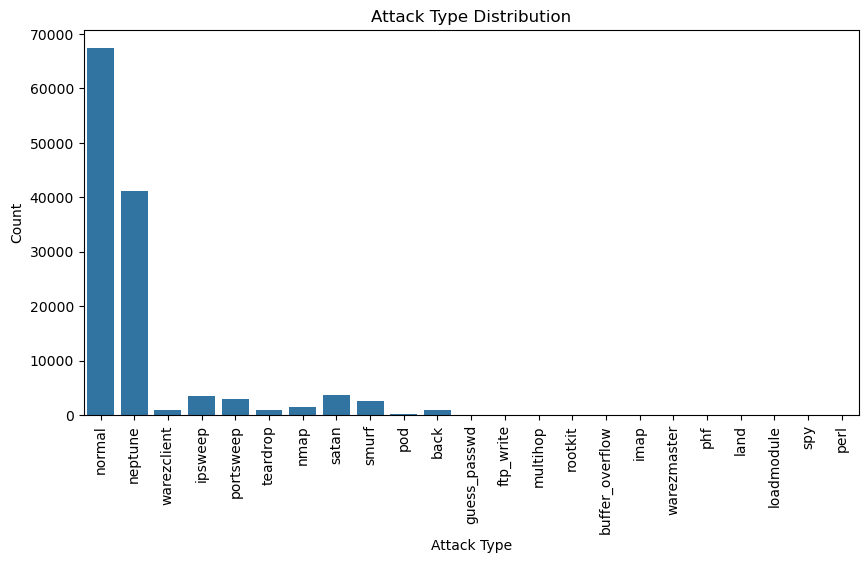

In [25]:
plt.figure(figsize=(10,5))

sns.countplot(x=train_df["class"])

plt.xticks(rotation=90)

plt.title("Attack Type Distribution")

plt.xlabel("Attack Type")

plt.ylabel("Count")

plt.show()

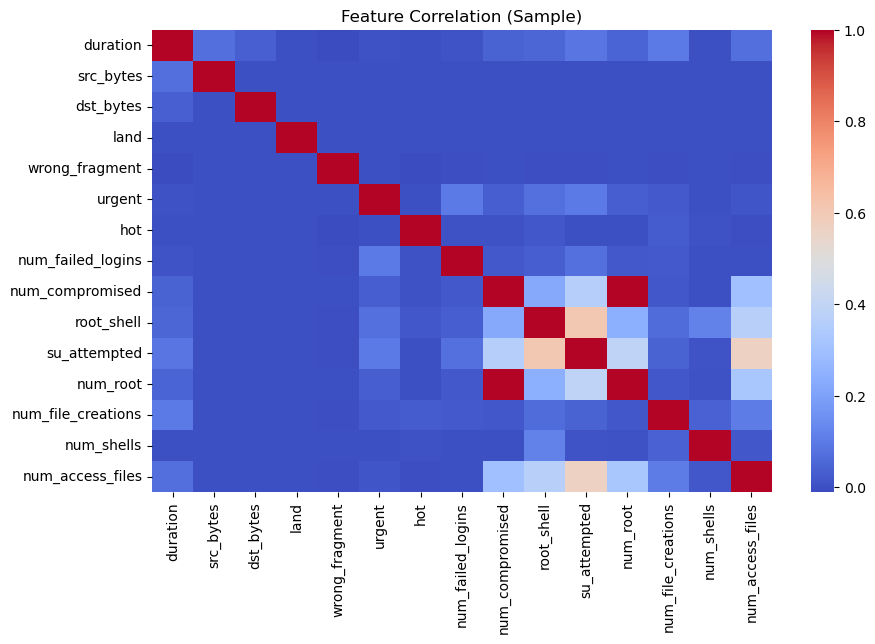

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(X.iloc[:, :15].corr(), cmap="coolwarm")

plt.title("Feature Correlation (Sample)")

plt.show()

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (100778, 117)
Testing samples: (25195, 117)


In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Save scaler
with open("../model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [29]:
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=0.3,
    random_state=42
)

rf.fit(X_train, y_train)

rf_acc = accuracy_score(y_test, rf.predict(X_test))

print("Random Forest Accuracy:", rf_acc)

Training Random Forest...
Random Forest Accuracy: 0.9867434014685453


In [30]:
print("Training Linear SVM...")

svm = SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    random_state=42
)

svm.fit(X_train, y_train)

svm_acc = accuracy_score(y_test, svm.predict(X_test))

print("SVM Accuracy:", svm_acc)

Training Linear SVM...
SVM Accuracy: 0.972931137130383


In [31]:
print("Training MLP...")

mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=150,
    random_state=42
)

mlp.fit(X_train, y_train)

mlp_acc = accuracy_score(y_test, mlp.predict(X_test))

print("MLP Accuracy:", mlp_acc)

Training MLP...
MLP Accuracy: 0.9941655090295693


In [32]:
print("Training AdaBoost...")

ada = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

ada.fit(X_train, y_train)

ada_acc = accuracy_score(y_test, ada.predict(X_test))

print("AdaBoost Accuracy:", ada_acc)

Training AdaBoost...


d:\anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Accuracy: 0.8405239134748959


In [33]:
from sklearn.ensemble import AdaBoostClassifier

print("Training AdaBoost...")

ada = AdaBoostClassifier(
    n_estimators=30,
    random_state=42
)

ada.fit(X_train, y_train)

ada_acc = accuracy_score(y_test, ada.predict(X_test))

print("AdaBoost Accuracy:", ada_acc)

Training AdaBoost...


d:\anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Accuracy: 0.8405239134748959


In [34]:
total = rf_acc + svm_acc + mlp_acc + ada_acc

weights = {
    "rf": rf_acc / total,
    "svm": svm_acc / total,
    "mlp": mlp_acc / total,
    "ada": ada_acc / total
}

print("Model Weights:", weights)

Model Weights: {'rf': 0.26005502149604076, 'svm': 0.25641481605456123, 'mlp': 0.2620111089028128, 'ada': 0.22151905354658524}


In [35]:
with open("../model/rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("../model/svm_model.pkl", "wb") as f:
    pickle.dump(svm, f)

with open("../model/mlp_model.pkl", "wb") as f:
    pickle.dump(mlp, f)

with open("../model/ada_model.pkl", "wb") as f:
    pickle.dump(ada, f)

with open("../model/model_weights.pkl", "wb") as f:
    pickle.dump(weights, f)

print("All models and weights saved successfully!")

All models and weights saved successfully!


In [36]:
import sys
print(sys.executable)

import sklearn
print(sklearn.__version__)

d:\anaconda\python.exe
1.5.1
